In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import shap
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pickle

print("✅ All libraries imported")

✅ All libraries imported


In [ ]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
store = pd.read_csv('store.csv')

train = train.merge(store, on='Store', how='left')
test  = test.merge(store, on='Store', how='left')

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Store shape: {store.shape}")
train.head()

Train shape: (1017209, 18)
Test shape:  (41088, 17)
Store shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
print("=== Data Types ===")
print(train.dtypes)
print("\n=== Missing Values ===")
print(train.isnull().sum()[train.isnull().sum() > 0])
print("\n=== Target Variable (Sales) Stats ===")
print(train['Sales'].describe())

=== Data Types ===
Store                          int64
DayOfWeek                      int64
Date                          object
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                  object
SchoolHoliday                  int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
dtype: object

=== Missing Values ===
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

=== Target Variable (Sales) Stats ===
count    

In [ ]:
import os
os.makedirs('assets', exist_ok=True)
print("✅ Assets folder created")

✅ Assets folder created


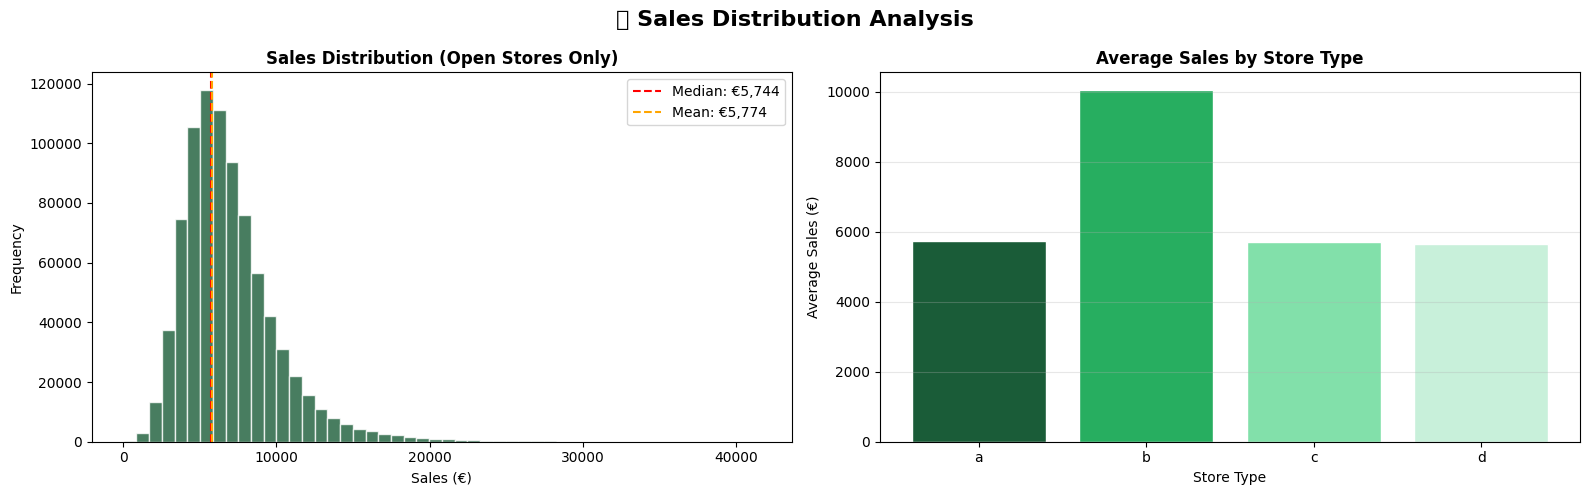

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('📊 Sales Distribution Analysis', fontsize=16, fontweight='bold')

# Sales distribution
axes[0].hist(train[train['Sales'] > 0]['Sales'], bins=50,
             color='#1a5c38', edgecolor='white', alpha=0.8)
axes[0].set_title('Sales Distribution (Open Stores Only)', fontweight='bold')
axes[0].set_xlabel('Sales (€)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train['Sales'].median(), color='red', linestyle='--',
                label=f"Median: €{train['Sales'].median():,.0f}")
axes[0].axvline(train['Sales'].mean(), color='orange', linestyle='--',
                label=f"Mean: €{train['Sales'].mean():,.0f}")
axes[0].legend()

# Sales by store type
store_type_sales = train.groupby('StoreType')['Sales'].mean()
axes[1].bar(store_type_sales.index, store_type_sales.values,
            color=['#1a5c38','#27ae60','#82e0aa','#c8f0da'],
            edgecolor='white')
axes[1].set_title('Average Sales by Store Type', fontweight='bold')
axes[1].set_xlabel('Store Type')
axes[1].set_ylabel('Average Sales (€)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('assets/eda_sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

✅ Feature engineering done
New features added: IsWeekend, IsPromoWeekend, CompetitionOpenMonths, IsPromo2Active, PromoStrength
Total features: 27


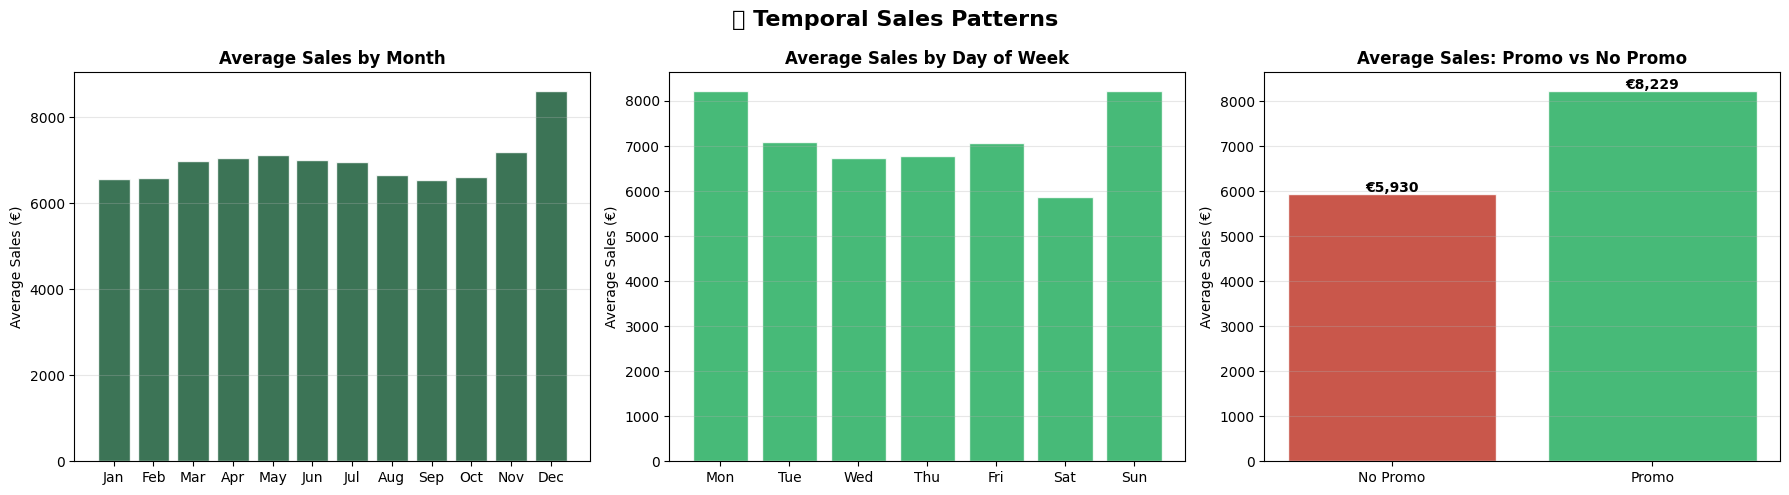

In [ ]:
train['Date'] = pd.to_datetime(train['Date'])
train['Year']       = train['Date'].dt.year
train['Month']      = train['Date'].dt.month
train['Day']        = train['Date'].dt.day
train['DayOfWeek']  = train['Date'].dt.dayofweek
train['WeekOfYear'] = train['Date'].dt.isocalendar().week.astype(int)

# ── New engineered features ──
train['IsWeekend'] = (train['DayOfWeek'] >= 5).astype(int)
train['IsPromoWeekend'] = ((train['Promo'] == 1) & (train['DayOfWeek'] >= 5)).astype(int)
train['CompetitionOpenMonths'] = ((train['Year'] - train['CompetitionOpenSinceYear']) * 12 +
                                   (train['Month'] - train['CompetitionOpenSinceMonth']))
train['CompetitionOpenMonths'] = train['CompetitionOpenMonths'].clip(lower=0).fillna(0)
train['IsPromo2Active'] = ((train['Promo2'] == 1) & (train['Promo2SinceYear'] > 0)).astype(int)
train['PromoStrength'] = train['Promo'] + train['Promo2']

print("✅ Feature engineering done")
print(f"New features added: IsWeekend, IsPromoWeekend, CompetitionOpenMonths, IsPromo2Active, PromoStrength")
print(f"Total features: {train.shape[1]}")

# ── EDA plots (same as before) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('⏱️ Temporal Sales Patterns', fontsize=16, fontweight='bold')

monthly = train[train['Sales']>0].groupby('Month')['Sales'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].bar(month_names, monthly.values, color='#1a5c38',
            edgecolor='white', alpha=0.85)
axes[0].set_title('Average Sales by Month', fontweight='bold')
axes[0].set_ylabel('Average Sales (€)')
axes[0].grid(True, alpha=0.3, axis='y')

dow = train[train['Sales']>0].groupby('DayOfWeek')['Sales'].mean()
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1].bar(day_names, dow.values, color='#27ae60',
            edgecolor='white', alpha=0.85)
axes[1].set_title('Average Sales by Day of Week', fontweight='bold')
axes[1].set_ylabel('Average Sales (€)')
axes[1].grid(True, alpha=0.3, axis='y')

promo = train[train['Sales']>0].groupby('Promo')['Sales'].mean()
axes[2].bar(['No Promo','Promo'], promo.values,
            color=['#c0392b','#27ae60'], edgecolor='white', alpha=0.85)
axes[2].set_title('Average Sales: Promo vs No Promo', fontweight='bold')
axes[2].set_ylabel('Average Sales (€)')
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(promo.values):
    axes[2].text(i, v + 50, f'€{v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('assets/eda_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

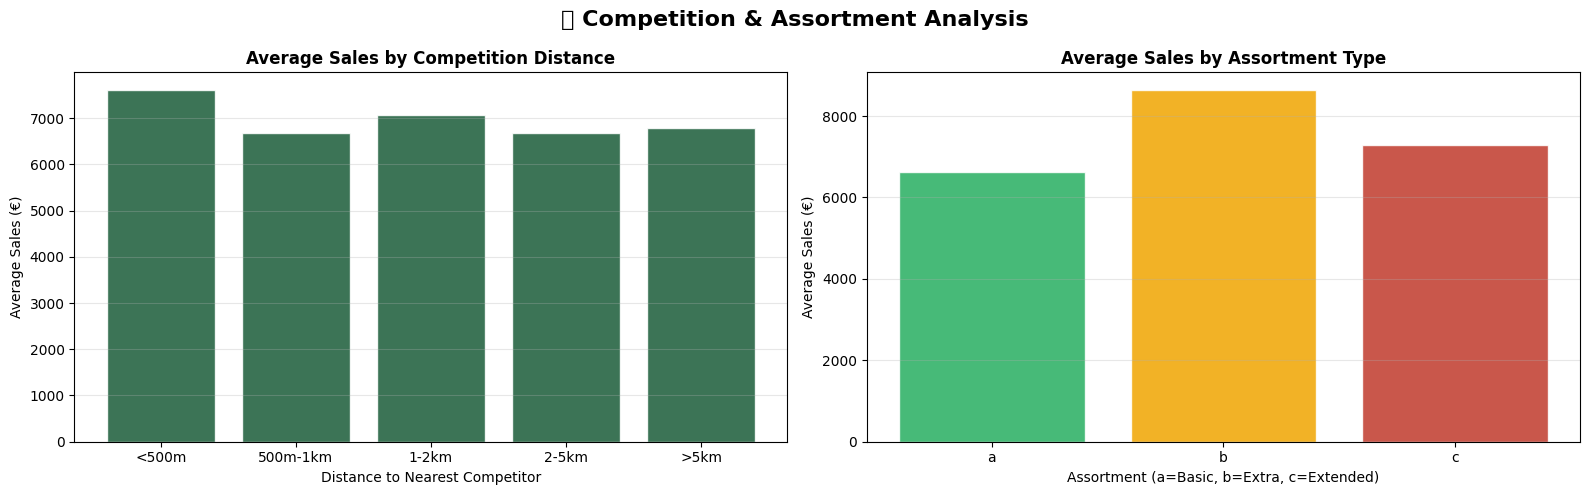

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('🏪 Competition & Assortment Analysis', fontsize=16, fontweight='bold')

# Competition distance vs sales
train_open = train[train['Sales'] > 0].copy()
train_open['DistanceBin'] = pd.cut(train_open['CompetitionDistance'],
                                    bins=[0,500,1000,2000,5000,50000],
                                    labels=['<500m','500m-1km','1-2km','2-5km','>5km'])
dist_sales = train_open.groupby('DistanceBin', observed=True)['Sales'].mean()
axes[0].bar(dist_sales.index, dist_sales.values,
            color='#1a5c38', edgecolor='white', alpha=0.85)
axes[0].set_title('Average Sales by Competition Distance', fontweight='bold')
axes[0].set_xlabel('Distance to Nearest Competitor')
axes[0].set_ylabel('Average Sales (€)')
axes[0].grid(True, alpha=0.3, axis='y')

# Assortment vs sales
assortment_sales = train_open.groupby('Assortment')['Sales'].mean()
axes[1].bar(assortment_sales.index, assortment_sales.values,
            color=['#27ae60','#f0a500','#c0392b'], edgecolor='white', alpha=0.85)
axes[1].set_title('Average Sales by Assortment Type', fontweight='bold')
axes[1].set_xlabel('Assortment (a=Basic, b=Extra, c=Extended)')
axes[1].set_ylabel('Average Sales (€)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('assets/eda_competition.png', dpi=150, bbox_inches='tight')
plt.show()

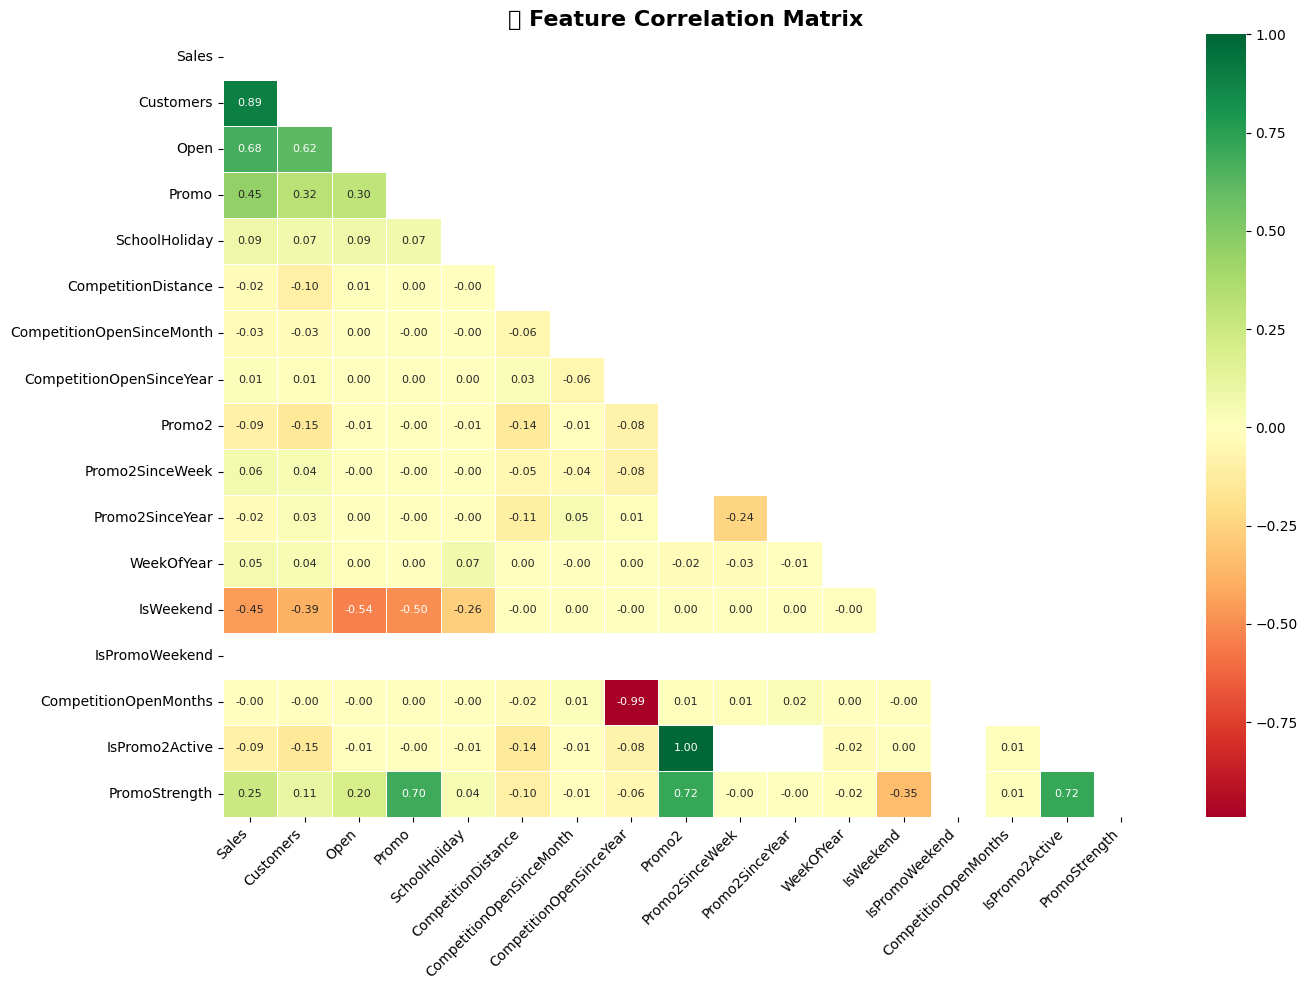

In [ ]:
numerical_cols = train.select_dtypes(include=['float64','int64']).columns.tolist()
numerical_cols = [c for c in numerical_cols if c not in ['Store']]

corr = train[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('🔗 Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('assets/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

# Fill missing values
train.fillna(0, inplace=True)
test.fillna(0, inplace=True)

# Deterministic encoding
encoding_maps = {
    'StateHoliday': {'0':0, 'a':1, 'b':2, 'c':3},
    'StoreType':    {'a':0, 'b':1, 'c':2, 'd':3},
    'Assortment':   {'a':0, 'b':1, 'c':2},
    'PromoInterval':{'':0, 'Jan,Apr,Jul,Oct':1,
                     'Feb,May,Aug,Nov':2, 'Mar,Jun,Sept,Dec':3}
}

for col, mapping in encoding_maps.items():
    train[col] = train[col].astype(str).map(mapping).fillna(0).astype(int)
    if col in test.columns:
        test[col] = test[col].astype(str).map(mapping).fillna(0).astype(int)

# Filter open stores only
train = train[train['Open'] == 1].copy()
train = train[train['Sales'] > 0].copy()

print(f"✅ Train after filtering closed stores: {train.shape}")
print("✅ Encoding complete")

✅ Train after filtering closed stores: (844338, 27)
✅ Encoding complete


In [ ]:
split_date = train['Date'].max() - pd.Timedelta(weeks=6)
print(f"Split date:   {split_date.date()}")
print(f"Train period: {train['Date'].min().date()} → {split_date.date()}")
print(f"Val period:   {split_date.date()} → {train['Date'].max().date()}")

train_split = train[train['Date'] <= split_date].copy()
val_split   = train[train['Date'] > split_date].copy()

drop_cols = ['Sales', 'Customers', 'Date']
X_train = train_split.drop(columns=drop_cols)
y_train = train_split['Sales']
X_val   = val_split.drop(columns=drop_cols)
y_val   = val_split['Sales']

print(f"\n✅ X_train: {X_train.shape}")
print(f"✅ X_val:   {X_val.shape}")

Split date:   2015-06-19
Train period: 2013-01-01 → 2015-06-19
Val period:   2015-06-19 → 2015-07-31

✅ X_train: (804056, 24)
✅ X_val:   (40282, 24)


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 28.2 MB/s eta 0:00:00


In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 300, 700),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth':        trial.suggest_int('max_depth', 4, 10),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 2.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
    preds = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))

print("🔍 Running Optuna (50 trials)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ Best RMSE from Optuna: {study.best_value:.2f}")
print(f"✅ Best params: {study.best_params}")

# Train final model with best params
t0 = time.time()
xgb_model = xgb.XGBRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
xgb_time = time.time() - t0

y_pred_xgb = xgb_model.predict(X_val)
xgb_rmse   = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
xgb_r2     = r2_score(y_val, y_pred_xgb)
xgb_mape   = np.mean(np.abs((y_val - y_pred_xgb) / y_val)) * 100

print(f"\n✅ XGBoost (Tuned) → RMSE: {xgb_rmse:.2f} | R²: {xgb_r2:.4f} | MAPE: {xgb_mape:.2f}% | Time: {xgb_time:.1f}s")

🔍 Running Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best RMSE from Optuna: 917.35
✅ Best params: {'n_estimators': 603, 'learning_rate': 0.13578095036695872, 'max_depth': 9, 'subsample': 0.8243218514286785, 'colsample_bytree': 0.7526750580919958, 'min_child_weight': 2, 'gamma': 0.1804325764208587, 'reg_alpha': 0.786218291123539, 'reg_lambda': 1.5348399672712982}

✅ XGBoost (Tuned) → RMSE: 917.35 | R²: 0.9098 | MAPE: 9.90% | Time: 56.8s


In [ ]:
print("Training LightGBM...")
t0 = time.time()

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=8,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50),
                         lgb.log_evaluation(100)])
lgb_time = time.time() - t0

y_pred_lgb  = lgb_model.predict(X_val)
lgb_rmse    = np.sqrt(mean_squared_error(y_val, y_pred_lgb))
lgb_r2      = r2_score(y_val, y_pred_lgb)
lgb_mape    = np.mean(np.abs((y_val - y_pred_lgb) / y_val)) * 100

print(f"\n✅ LightGBM → RMSE: {lgb_rmse:.2f} | R²: {lgb_r2:.4f} | MAPE: {lgb_mape:.2f}% | Time: {lgb_time:.1f}s")

Training LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 2.47115e+06
[200]	valid_0's l2: 1.55272e+06
[300]	valid_0's l2: 1.28788e+06
[400]	valid_0's l2: 1.17383e+06
[500]	valid_0's l2: 1.09264e+06
Did not meet early stopping. Best iteration is:
[500]	valid_0's l2: 1.09264e+06

✅ LightGBM → RMSE: 1045.29 | R²: 0.8829 | MAPE: 11.79% | Time: 31.9s


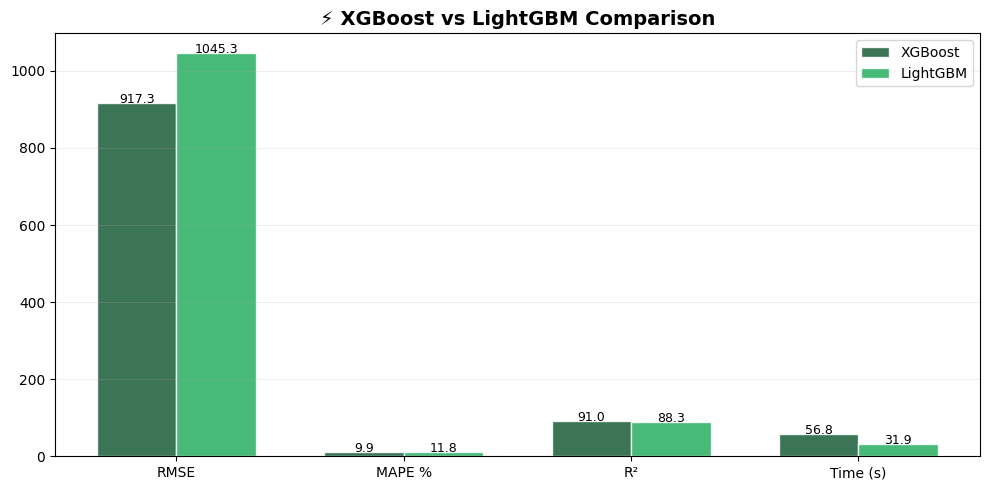

Winner: XGBoost


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

metrics = ['RMSE', 'MAPE %', 'R²', 'Time (s)']
xgb_vals = [xgb_rmse, xgb_mape, xgb_r2*100, xgb_time]
lgb_vals  = [lgb_rmse, lgb_mape, lgb_r2*100, lgb_time]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, xgb_vals, width, label='XGBoost',
               color='#1a5c38', edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + width/2, lgb_vals, width, label='LightGBM',
               color='#27ae60', edgecolor='white', alpha=0.85)

ax.set_title('⚡ XGBoost vs LightGBM Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.2, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('assets/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

winner = 'LightGBM' if lgb_rmse < xgb_rmse else 'XGBoost'
print(f"Winner: {winner}")

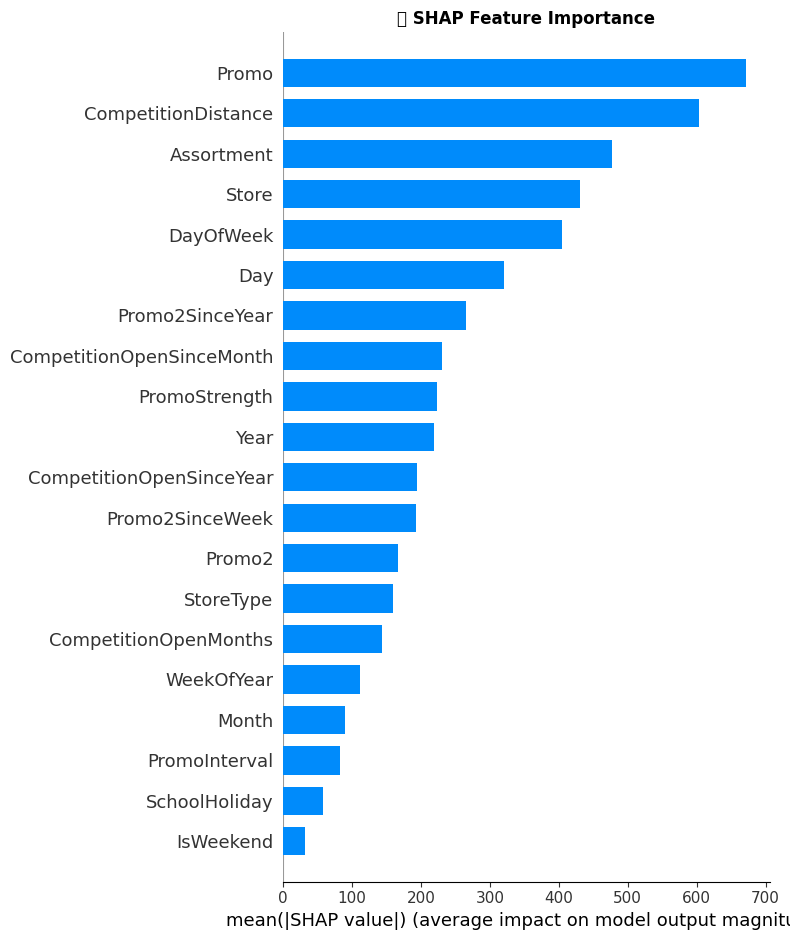

In [ ]:
# Use winner model for SHAP
best_model = lgb_model if lgb_rmse < xgb_rmse else xgb_model

explainer  = shap.Explainer(best_model)
shap_vals  = explainer(X_val.sample(1000, random_state=42))

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_val.sample(1000, random_state=42),
                  show=False, plot_type='bar')
plt.title('🌟 SHAP Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('assets/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

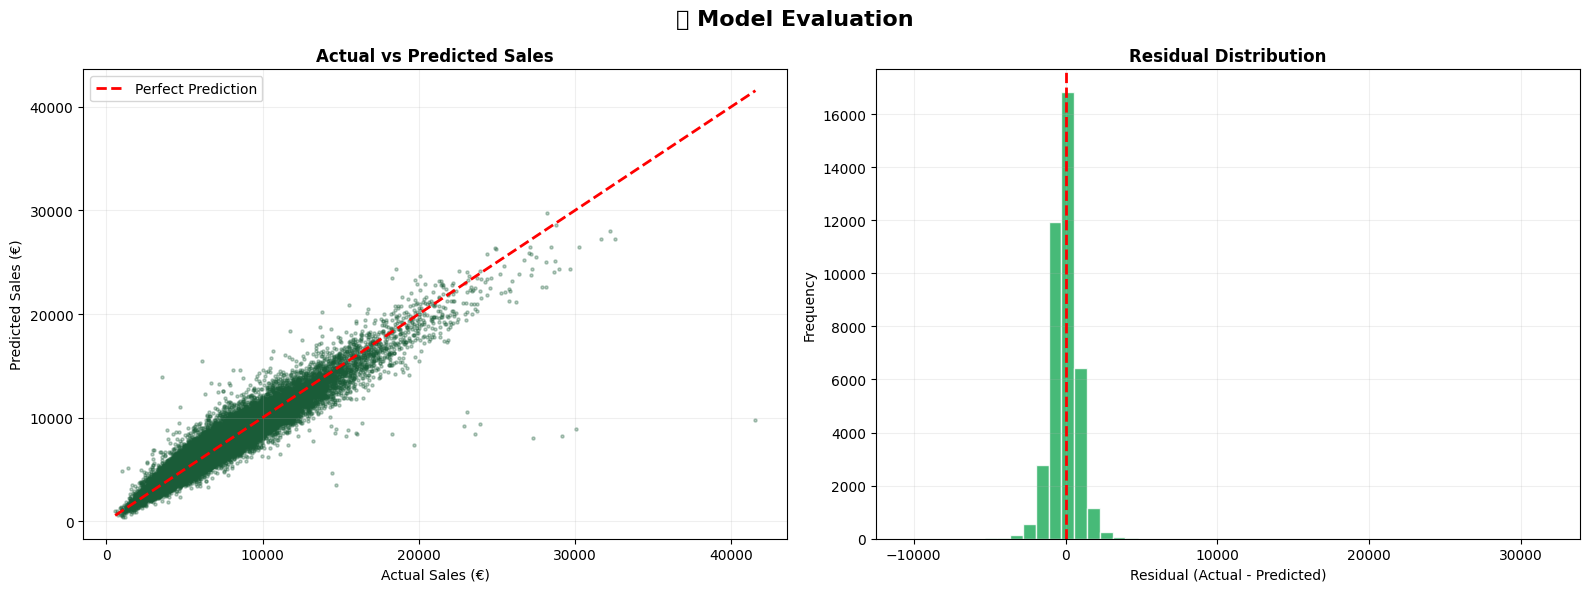

In [ ]:
y_pred_best = lgb_model.predict(X_val) if lgb_rmse < xgb_rmse else xgb_model.predict(X_val)
residuals   = y_val - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('📈 Model Evaluation', fontsize=16, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_val, y_pred_best, alpha=0.3, color='#1a5c38', s=5)
axes[0].plot([y_val.min(), y_val.max()],
             [y_val.min(), y_val.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title('Actual vs Predicted Sales', fontweight='bold')
axes[0].set_xlabel('Actual Sales (€)')
axes[0].set_ylabel('Predicted Sales (€)')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Residuals
axes[1].hist(residuals, bins=50, color='#27ae60',
             edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('assets/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
winner_model = lgb_model if lgb_rmse < xgb_rmse else xgb_model
winner_name  = 'LightGBM' if lgb_rmse < xgb_rmse else 'XGBoost'

with open('rossmann_model.pkl', 'wb') as f:
    pickle.dump(winner_model, f)

print(f"✅ {winner_name} saved as rossmann_model.pkl")
print(f"✅ Final RMSE: {min(lgb_rmse, xgb_rmse):.2f}")
print(f"✅ Final R²:   {max(lgb_r2, xgb_r2):.4f}")

✅ XGBoost saved as rossmann_model.pkl
✅ Final RMSE: 917.35
✅ Final R²:   0.9098
